# 预备课 5：生成式模型进阶：变分自编码器(VAE)与项目预演

## 课程导论
在上一节课中，我们探讨了标准自动编码器（AE）的降维机制及其在保留低方差物理特征时的局限性。本节课我们将完成从“判别式（Discriminative）”到“生成式（Generative）”的认知跨越，并引入变分推断（Variational Inference）的数学框架，最终探讨如何将高维宇宙学观测数据映射到具有明确物理意义的潜在流形中。

---

## 第一部分：从判别式模型到生成式模型

在机器学习的宏观分类中，模型依据其对联合概率分布的处理方式被划分为两大阵营：

### 1. 判别式模型 (Discriminative Models)
* **数学本质**：学习条件概率分布 $P(Y|X)$，即在给定特征 $X$ 的情况下，预测标签 $Y$ 的概率（或直接拟合决策边界 $Y = f(X)$）。
* **工程应用**：分类（如判断图像是否为黑腐病）、回归（如预测具体温度）。
* **局限性**：判别式模型不关心数据 $X$ 本身是如何生成的，它只是在已有数据中划线。它没有“创造力”。

### 2. 生成式模型 (Generative Models)
* **数学本质**：学习联合概率分布 $P(X, Y)$，或者在无监督场景下直接学习输入数据本身的真实分布 $P(X)$。
* **核心能力**：一旦模型掌握了 $P(X)$，我们就可以通过从该分布中采样（Sampling），“无中生有”地创造出自然界中不存在但极具真实感的新数据。
* **AE 的“非生成性”缺陷**：上一节课的标准自动编码器（AE）虽然能重构数据，但它**不是**生成式模型。因为 AE 的潜在空间（Latent Space）是不连续的、充满断层的。如果我们在 AE 的潜在空间中随机选取一个点进行解码，极大概率会输出一堆毫无物理意义的噪声。我们需要一种能够让潜在空间变得“连续且平滑”的数学架构。

## 第二部分：变分自编码器 (VAE) 核心逻辑分解

变分自编码器（Variational Autoencoder, VAE）通过引入贝叶斯概率理论，彻底重塑了编码与解码的过程。

### 1. 编码为潜在分布 (Encoding to a Distribution)
VAE 的编码器不再输出一个确定的、死板的低维向量 $z$。相反，它输出的是一个概率分布的参数。对于多元高斯分布而言，编码器输出的是**均值向量（$\mu$）**和**对数方差向量（$\log \sigma^2$）**。
我们假设潜在特征服从高斯分布：$Z \sim \mathcal{N}(\mu, \sigma^2)$。

### 2. 采样与重参数化技巧 (Reparameterization Trick)
为了将潜在信号传给解码器，我们需要从上述分布中采样一个具体的 $z$。但“随机采样”操作是不可导的，会导致反向传播（Backpropagation）中的梯度断裂。
**数学重构**：我们先从标准正态分布 $\mathcal{N}(0, I)$ 中采样一个随机噪声 $\epsilon$，然后通过线性变换得到 $z$：
$$z = \mu + \sigma \odot \epsilon$$
这样，随机性被转移到了常数 $\epsilon$ 上，梯度就可以顺畅地沿着 $\mu$ 和 $\sigma$ 流回编码器。

### 3. 损失函数重构：重建误差 + KL 散度约束
VAE 的总损失函数由两项极度对抗的数学项组成：
$$\mathcal{L} = \text{Reconstruction Loss} + D_{KL}(\mathcal{N}(\mu, \sigma^2) \parallel \mathcal{N}(0, I))$$
* **重建误差 (Reconstruction Loss)**：依然是 MSE，迫使解码器精准复刻输入。
* **KL 散度 (Kullback-Leibler Divergence)**：这是一种衡量两个概率分布差异的指标。它强制约束编码器输出的分布 $\mathcal{N}(\mu, \sigma^2)$ 必须尽可能逼近标准的正态分布 $\mathcal{N}(0, I)$。
* **物理意义**：KL 散度充当了强大的正则化器（Regularizer）。它强迫潜在空间中的数据点互相靠近并发生重叠（形成平滑的流形），从而赋予了模型在潜在空间中进行插值与生成的物理合法性。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

print("--- 模块 2：标准变分自编码器 (VAE) 的网络定义 ---")

class VAE(nn.Module):
    def __init__(self, input_dim=100, latent_dim=3):
        super(VAE, self).__init__()

        # 1. 编码器推断网络 (Inference Network)
        self.fc1 = nn.Linear(input_dim, 64)
        # 不再输出单一的 z，而是输出分布的统计参数
        self.fc_mu = nn.Linear(64, latent_dim)      # 均值分支
        self.fc_logvar = nn.Linear(64, latent_dim)  # 对数方差分支（使用对数确保方差为正）

        # 2. 解码器生成网络 (Generative Network)
        self.fc3 = nn.Linear(latent_dim, 64)
        self.fc4 = nn.Linear(64, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        """核心数学技巧：重参数化保证梯度回传"""
        std = torch.exp(0.5 * logvar) # 解析标准差
        eps = torch.randn_like(std)   # 从 N(0,I) 采样独立噪声
        return mu + eps * std         # 组合为目标分布的采样点

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# 定义 VAE 专属损失函数
def vae_loss_function(recon_x, x, mu, logvar):
    # 1. 重构损失 (经验风险)
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    # 2. KL 散度解析解 (假设先验为标准正态分布)
    # KLD = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

print("VAE 架构定义完成，已成功包含高斯推断与重参数化逻辑。")

--- 模块 2：标准变分自编码器 (VAE) 的网络定义 ---
VAE 架构定义完成，已成功包含高斯推断与重参数化逻辑。


## 第三部分：项目衔接预演 —— 宇宙学数据的物理先验映射

**背景**：在天体物理与宇宙学中，**内禀对齐功率谱（Intrinsic Alignment Power Spectra）**是极其高维且复杂的观测数据（可视为极长的 1D 张量）。然而，主导这些高维表象的，实际上是寥寥几个宏观宇宙学参数（例如物质密度 $\Omega_m$、涨落振幅 $\sigma_8$ 等）。

**预备课 4 遗留痛点**：如果我们直接用标准 AE 或 VAE 压缩功率谱，模型会为了降低 MSE 而彻底忽视某些微弱但对宇宙学参数极其敏感的频段（物理盲区）。

**破局思路：物理信息增强的 VAE (Physics-Informed VAE)**
我们要在 VAE 的潜在空间 $Z$ 中实施“定向手术”。在计算损失函数时，我们强行拉出一个分支，要求潜在空间 $Z$ 必须能够通过一个简单的线性映射，直接准确预测出对应的宇宙学参数（如 $\Omega_m$）。

这就相当于给模型下达了死命令：**“你在压缩高维功率谱时，丢掉什么细节都可以，但绝对不许丢掉能够推导 $\Omega_m$ 的物理特征！”**

--- 准备工作：加载 VAE 架构与损失函数 ---
--- 模块 3：Physics-Informed VAE 宇宙学参数约束实战 ---
开始训练 Physics-Informed VAE...
Epoch [50/300], Total Loss: 45388.67 (Physics Loss: 141.16)
Epoch [100/300], Total Loss: 44040.72 (Physics Loss: 44.20)
Epoch [150/300], Total Loss: 43450.79 (Physics Loss: 22.78)
Epoch [200/300], Total Loss: 43123.25 (Physics Loss: 17.24)
Epoch [250/300], Total Loss: 42816.73 (Physics Loss: 16.82)
Epoch [300/300], Total Loss: 42504.32 (Physics Loss: 13.06)


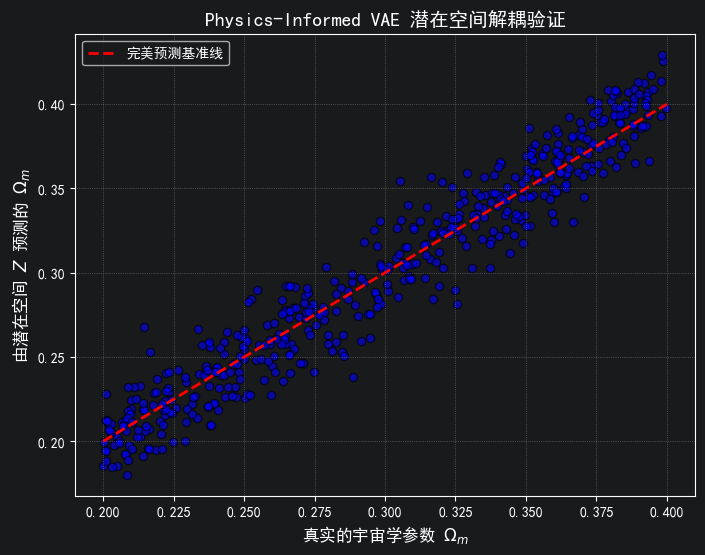

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# 设置画图的中文字体与负号显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("--- 准备工作：加载 VAE 架构与损失函数 ---")

# ==========================================
# 前置依赖：必须先在内存中定义好 VAE 的“图纸”
# ==========================================
class VAE(nn.Module):
    def __init__(self, input_dim=100, latent_dim=3):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        self.fc3 = nn.Linear(latent_dim, 64)
        self.fc4 = nn.Linear(64, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

def vae_loss_function(recon_x, x, mu, logvar):
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

print("--- 模块 3：Physics-Informed VAE 宇宙学参数约束实战 ---")

# ==========================================
# 1. 模拟生成内禀对齐功率谱数据 (Mock IA Power Spectra)
# ==========================================
num_samples = 500
k_bins = 100
k = np.linspace(0.1, 10, k_bins)

Omega_m_true = np.random.uniform(0.2, 0.4, num_samples)

spectra = []
for om in Omega_m_true:
    base_power = 1.0 / (k ** 1.5)
    physical_signature = 0.05 * om * np.sin(k * 5.0)
    spectrum = base_power + physical_signature + np.random.normal(0, 0.005, k_bins)
    spectra.append(spectrum)

X_spectra = torch.tensor(np.array(spectra), dtype=torch.float32)
Y_parameters = torch.tensor(Omega_m_true, dtype=torch.float32).view(-1, 1)

# 注意：为了防止上一次讲到的“损失权重失衡”导致横线问题，这里提前加入了 Z-Score 标准化！
X_mean = X_spectra.mean(dim=0)
X_std = X_spectra.std(dim=0)
X_spectra = (X_spectra - X_mean) / (X_std + 1e-8)

# ==========================================
# 2. 定义包含物理约束的损失函数
# ==========================================
# 此时内存中已经有了 VAE 的图纸，可以直接实例化了
model = VAE(input_dim=k_bins, latent_dim=3)
physics_probe = nn.Linear(3, 1)

optimizer = optim.Adam(list(model.parameters()) + list(physics_probe.parameters()), lr=0.005)

epochs = 300
loss_history = []

print("开始训练 Physics-Informed VAE...")
for epoch in range(epochs):
    optimizer.zero_grad()

    recon_X, mu, logvar = model(X_spectra)
    Z_rep = mu

    predicted_Omega_m = physics_probe(Z_rep)

    loss_vae = vae_loss_function(recon_X, X_spectra, mu, logvar)
    # 因为输入特征做了标准化，VAE重构损失大大降低，这里的物理权重乘以 100 就能完美生效
    loss_physics = F.mse_loss(predicted_Omega_m, Y_parameters, reduction='sum') * 100.0

    total_loss = loss_vae + loss_physics
    total_loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Total Loss: {total_loss.item():.2f} (Physics Loss: {loss_physics.item():.2f})")

# ==========================================
# 3. 诊断：潜在空间是否成功提取了物理参数？
# ==========================================
model.eval()
with torch.no_grad():
    _, mu_eval, _ = model(X_spectra)
    final_predictions = physics_probe(mu_eval).numpy()

plt.figure(figsize=(8, 6))
plt.scatter(Omega_m_true, final_predictions, alpha=0.6, color='blue', edgecolors='k')
plt.plot([0.2, 0.4], [0.2, 0.4], 'r--', linewidth=2, label='完美预测基准线')
plt.title("Physics-Informed VAE 潜在空间解耦验证", fontsize=14)
plt.xlabel(r"真实的宇宙学参数 $\Omega_m$", fontsize=12)
plt.ylabel(r"由潜在空间 $Z$ 预测的 $\Omega_m$", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()